# Tetouan GridWatch: Week 10 Research Milestone

**Forecast horizon:** 30 minutes. **Targets:** three distribution zones. **Status:** executed classroom benchmark and historical replay.

This notebook reads verified outputs from the reproducible source pipeline. It does not silently retrain or tune on test results. Future chapters remain planned. This is an interim research report, not the finished 15-week project.

Questions: How accurately can past measurements forecast demand? Does a direct event classifier improve alerts relative to forecast scores? How does seasonal change affect an alert operating point?

**Source:** [UCI Tetouan dataset](https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city). Retain source measurement units. The variables table does not establish kWh. Thresholds indicate research-defined high demand, not overload or outages.

## 1. Locate the project and verified outputs

Run from the extracted project root or its `notebooks` directory. The saved outputs can be read before running cells. To regenerate all models, run `run_experiment.ps1` as described in the README. This first cell supports the current computer and an extracted project directory.

In [1]:
from pathlib import Path
import json
import os
import sys
import pandas as pd
roots = [Path.cwd(), *Path.cwd().parents]
if os.environ.get("GRIDWATCH_ROOT"):
    roots.insert(0, Path(os.environ["GRIDWATCH_ROOT"]))
roots.append(Path(r"D:\Kỳ I 2026-2027\Học thống kê\Midterm_Tetouan_GridWatch"))
ROOT = next((p for p in roots if (p / "src/gridwatch/experiment.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Extract the project and set GRIDWATCH_ROOT to its folder.")
sys.path.insert(0, str(ROOT / "src"))
summary = json.loads((ROOT / "artifacts/experiment_summary.json").read_text())
print("Stage:", summary["stage"])
print("Selected forecaster:", summary["selected_regressor"])


Stage: week_10_initial_benchmark
Selected forecaster: Linear


## 2. Source audit and exploratory statistics

The downloaded CSV contains 52,416 rows. UCI's instance count is 52,417; this discrepancy is documented rather than filled with a fabricated row. Timestamp spacing is exactly ten minutes within the observed period. No cells are missing and no timestamps are duplicated. Peaks remain in the data because high demand is a prediction target. Correlation does not establish weather causality.

In [2]:
audit = json.loads((ROOT / "artifacts/data_audit.json").read_text())
print(json.dumps(audit, indent=2))
print(pd.read_csv(ROOT / "reports/descriptive_statistics.csv").to_string(index=False))


{
  "source": "https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city",
  "source_csv_sha256": "ca8b2f30cf07dd872cb7f2aa45dac110ee38dbe5fc5910a6ff4bcc530dae3a40",
  "rows": 52416,
  "columns": [
    "timestamp",
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse",
    "diffuse",
    "zone_1",
    "zone_2",
    "zone_3"
  ],
  "start": "2017-01-01 00:00:00",
  "end": "2017-12-30 23:50:00",
  "missing_cells": 0,
  "duplicate_rows": 0,
  "duplicate_timestamps": 0,
  "timestamps_sorted": true,
  "irregular_intervals": 0,
  "missing_expected_timestamps": 0,
  "nonfinite_numeric_cells": 0,
  "negative_target_cells": 0,
  "target_units": "Not specified in the UCI variables table; use original source units.",
  "uci_metadata_instances": 52417,
  "metadata_count_note": "The CSV row count is authoritative for this experiment; UCI metadata may include the header."
}
Unnamed: 0  temperature  humidity  wind_speed  general_diffuse   diffuse    zone_1    zone

Annual and intraday demand patterns reveal different seasonal behavior across zones.

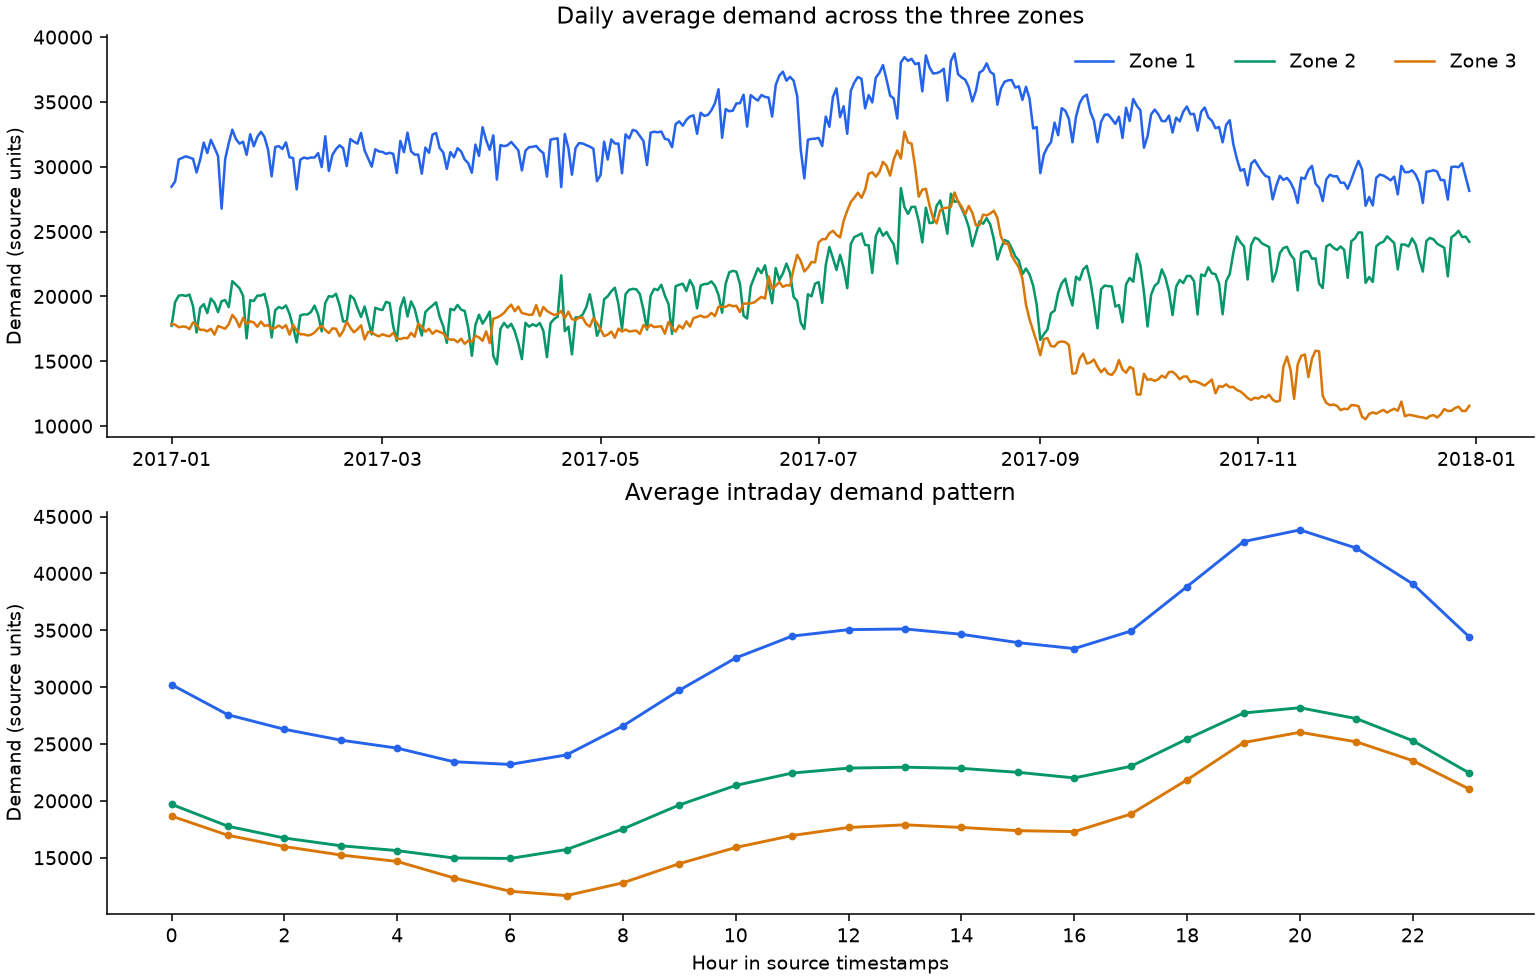

Descriptive correlations across observed variables.

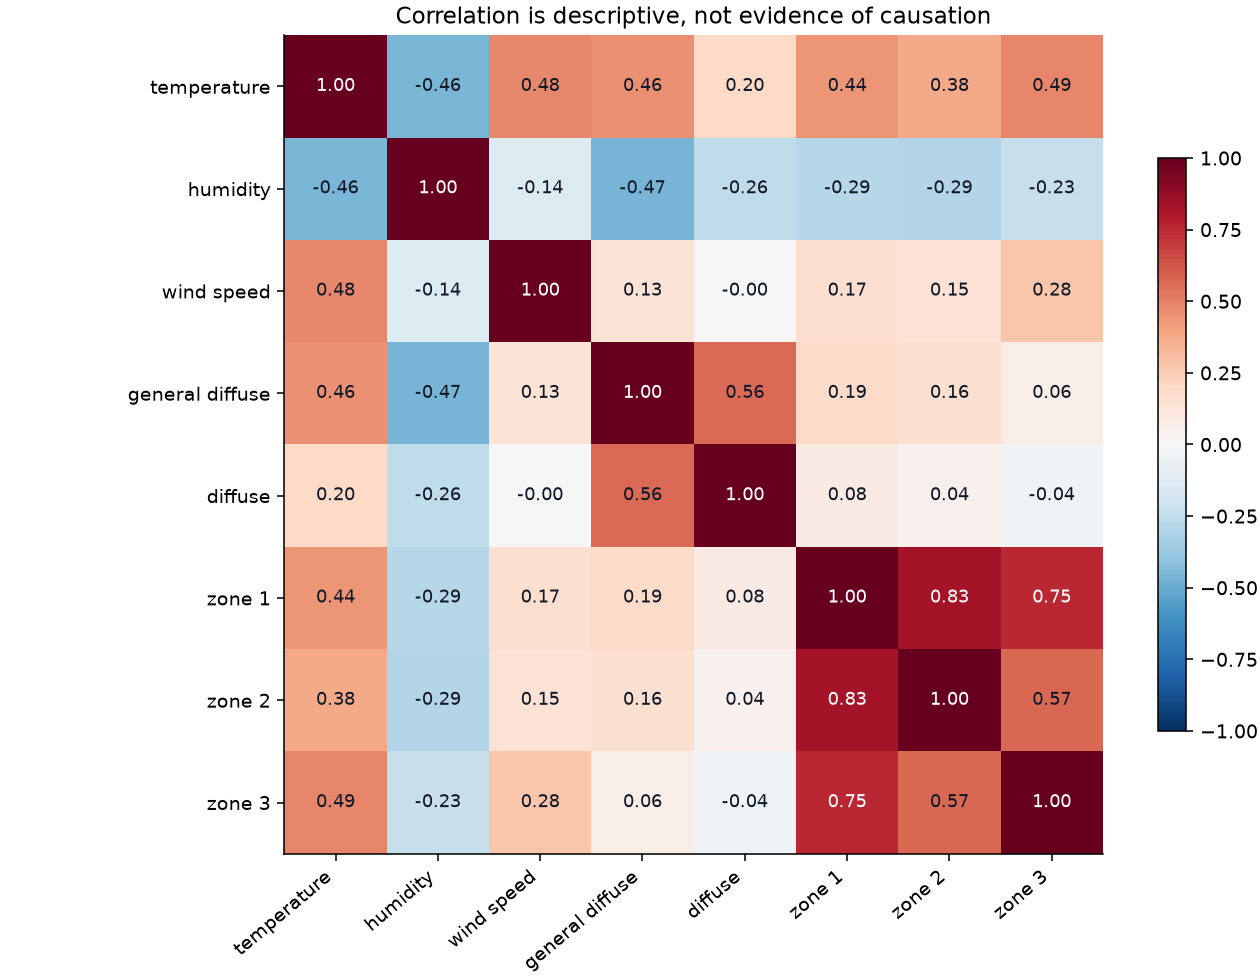

## 3. Temporal contract and features

At origin t, inputs include current weather, current and previous demand, trailing means and deviations, previous-day demand at the target slot, and known calendar values for t+30 minutes. The previous week supplies the longest lag. Future measured weather is excluded. All scalers fit training data only.

Split boundaries use the original series' 70% and 85% positions. After history requirements and boundary purging, the actual sample counts differ from exact 70/15/15 percentages. Training labels end before validation begins, and validation labels end before test begins. Recent observed test history is available at each subsequent replay origin. The split is provisional until the peer groups agree.

In [3]:
manifest = json.loads((ROOT / "artifacts/split_manifest.json").read_text())
print("Features:", manifest["feature_count"])
print("Validation starts:", manifest["validation_start"])
print("Test starts:", manifest["test_start"])
print(pd.DataFrame(manifest["samples"]).T.to_string())


Features: 48
Validation starts: 2017-09-12 19:10:00
Test starts: 2017-11-06 09:30:00
             rows         first_origin          last_origin          last_target
train       35680  2017-01-08 00:00:00  2017-09-12 18:30:00  2017-09-12 19:00:00
validation   7859  2017-09-12 19:10:00  2017-11-06 08:50:00  2017-11-06 09:20:00
test         7860  2017-11-06 09:30:00  2017-12-30 23:20:00  2017-12-30 23:50:00


In [4]:
import unittest
suite = unittest.defaultTestLoader.discover(str(ROOT / "tests"))
runner = unittest.TextTestRunner(stream=sys.stdout, verbosity=2)
result = runner.run(suite)
assert result.wasSuccessful()


test_no_positive_events_does_not_report_perfect_recall (test_alert_contract.AlertContract.test_no_positive_events_does_not_report_perfect_recall) ... ok
test_ties_cannot_break_validation_false_alarm_budget (test_alert_contract.AlertContract.test_ties_cannot_break_validation_false_alarm_budget) ... ok
test_future_changes_cannot_change_current_features (test_temporal_contract.TemporalContract.test_future_changes_cannot_change_current_features) ... ok
test_targets_and_boundaries (test_temporal_contract.TemporalContract.test_targets_and_boundaries) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.194s

OK


## 4. Classroom forecasting benchmark

Persistence uses the latest observed demand. The daily baseline uses yesterday's same target slot. We compare linear regression, Ridge, Lasso, KNN, decision tree and random forest on identical samples. We select the lowest validation MAE averaged across the three zones. Models use bounded configurations; no exhaustive search is claimed.

Chapter 10's SVM classification method is used in the event-classification experiment below. It is not presented as classroom SVR. Chapters 11 onward have not been implemented.

In [5]:
validation = pd.read_csv(ROOT / "reports/regression_validation.csv")
print(validation[validation.zone == "average"][["model","mae","rmse","r2","train_seconds"]].sort_values("mae").to_string(index=False))


        model         mae        rmse       r2  train_seconds
       Linear  318.988078  464.876867 0.989745       0.172171
        Lasso  338.726492  492.597367 0.988684       2.322908
        Ridge  351.448413  504.707322 0.987934       0.112421
  Persistence  791.318529 1179.605860 0.938342       0.000000
 Previous day 1024.453405 1469.754232 0.898801       0.000000
Random Forest 1223.019437 1721.657539 0.829683      42.944366
Decision Tree 1543.148923 2149.850336 0.737434       2.406488
          KNN 1698.797652 2197.801564 0.699352       0.090533


Model selection uses validation only.

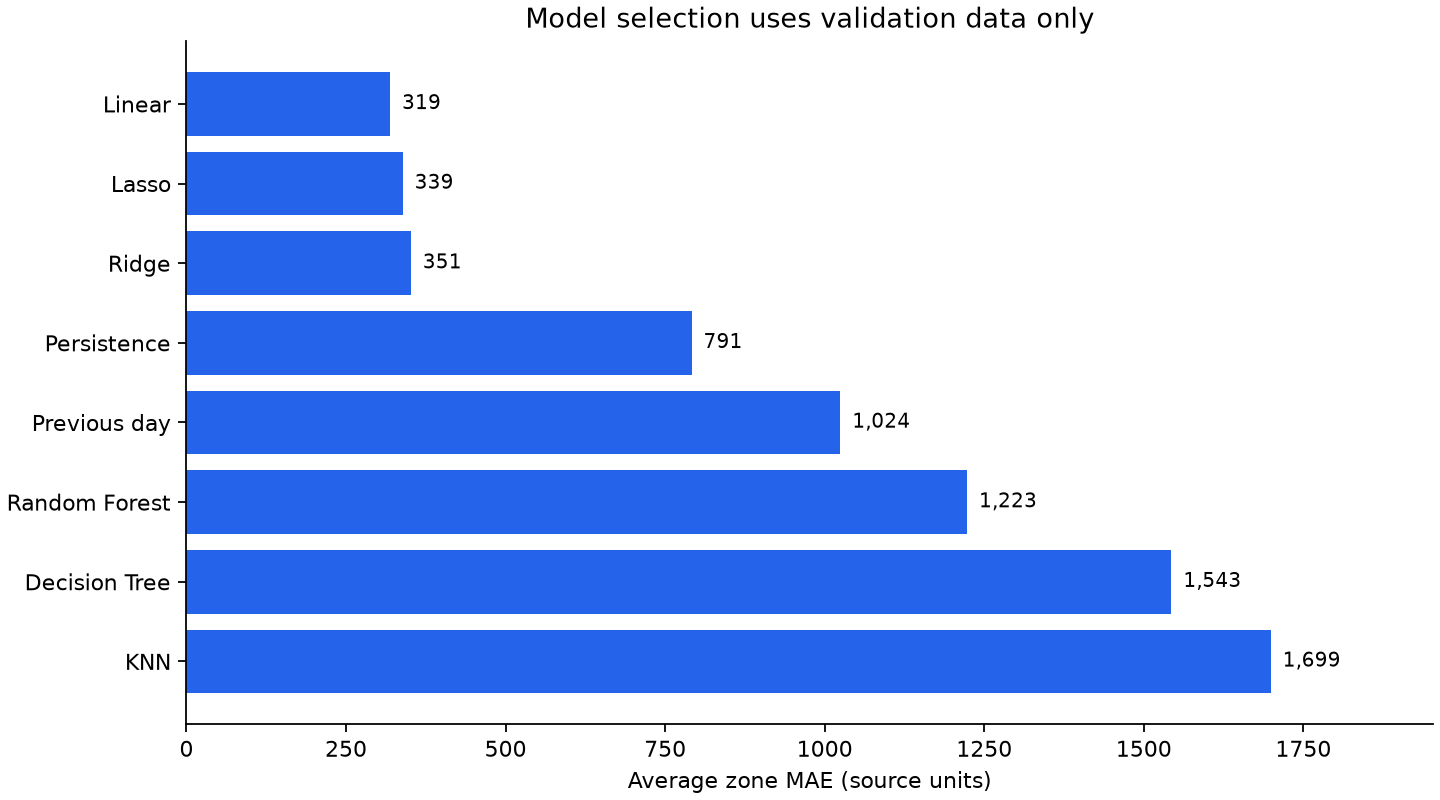

## 5. Frozen held-out evaluation

The selected forecaster and all alert operating points were fixed before this test evaluation. MAE is the average absolute point error. Lower MAE is better. R-squared is reported in addition, not as a percent forecast accuracy. Average-zone MAE weights the three zones equally in their original units.

In [6]:
test = pd.read_csv(ROOT / "reports/regression_test.csv")
print(test[["model","zone","mae","rmse","r2","peak_mae","peak_samples"]].to_string(index=False))
averages = test[test.zone == "average"].set_index("model")
gain = 100 * (1 - averages.loc["Linear","mae"] / averages.loc["Persistence","mae"])
print(f"MAE reduction versus persistence: {gain:.2f}% on this test period.")


       model    zone         mae        rmse       r2    peak_mae  peak_samples
      Linear  zone_1  443.886924  602.335084 0.990116 1143.248541           9.0
      Linear  zone_2  343.163128  516.824954 0.991449  448.488357        1913.0
      Linear  zone_3  284.887773  491.012197 0.978639         NaN           0.0
      Linear average  357.312608  536.724078 0.986735         NaN           NaN
 Persistence  zone_1  974.349332 1405.239488 0.946205 2280.692858           9.0
 Persistence  zone_2  835.310967 1215.137068 0.952730 1080.629265        1913.0
 Persistence  zone_3  520.151409  848.188333 0.936260         NaN           0.0
 Persistence average  776.603903 1156.188296 0.945065         NaN           NaN
Previous day  zone_1  985.253814 1486.773818 0.939782 3095.901986           9.0
Previous day  zone_2 1147.998718 1734.422605 0.903697 1088.618337        1913.0
Previous day  zone_3  722.495345 1338.799659 0.841196         NaN           0.0
Previous day average  951.915959 1519.99

Three test days shown for inspection. Targets were observed after each forecast was issued.

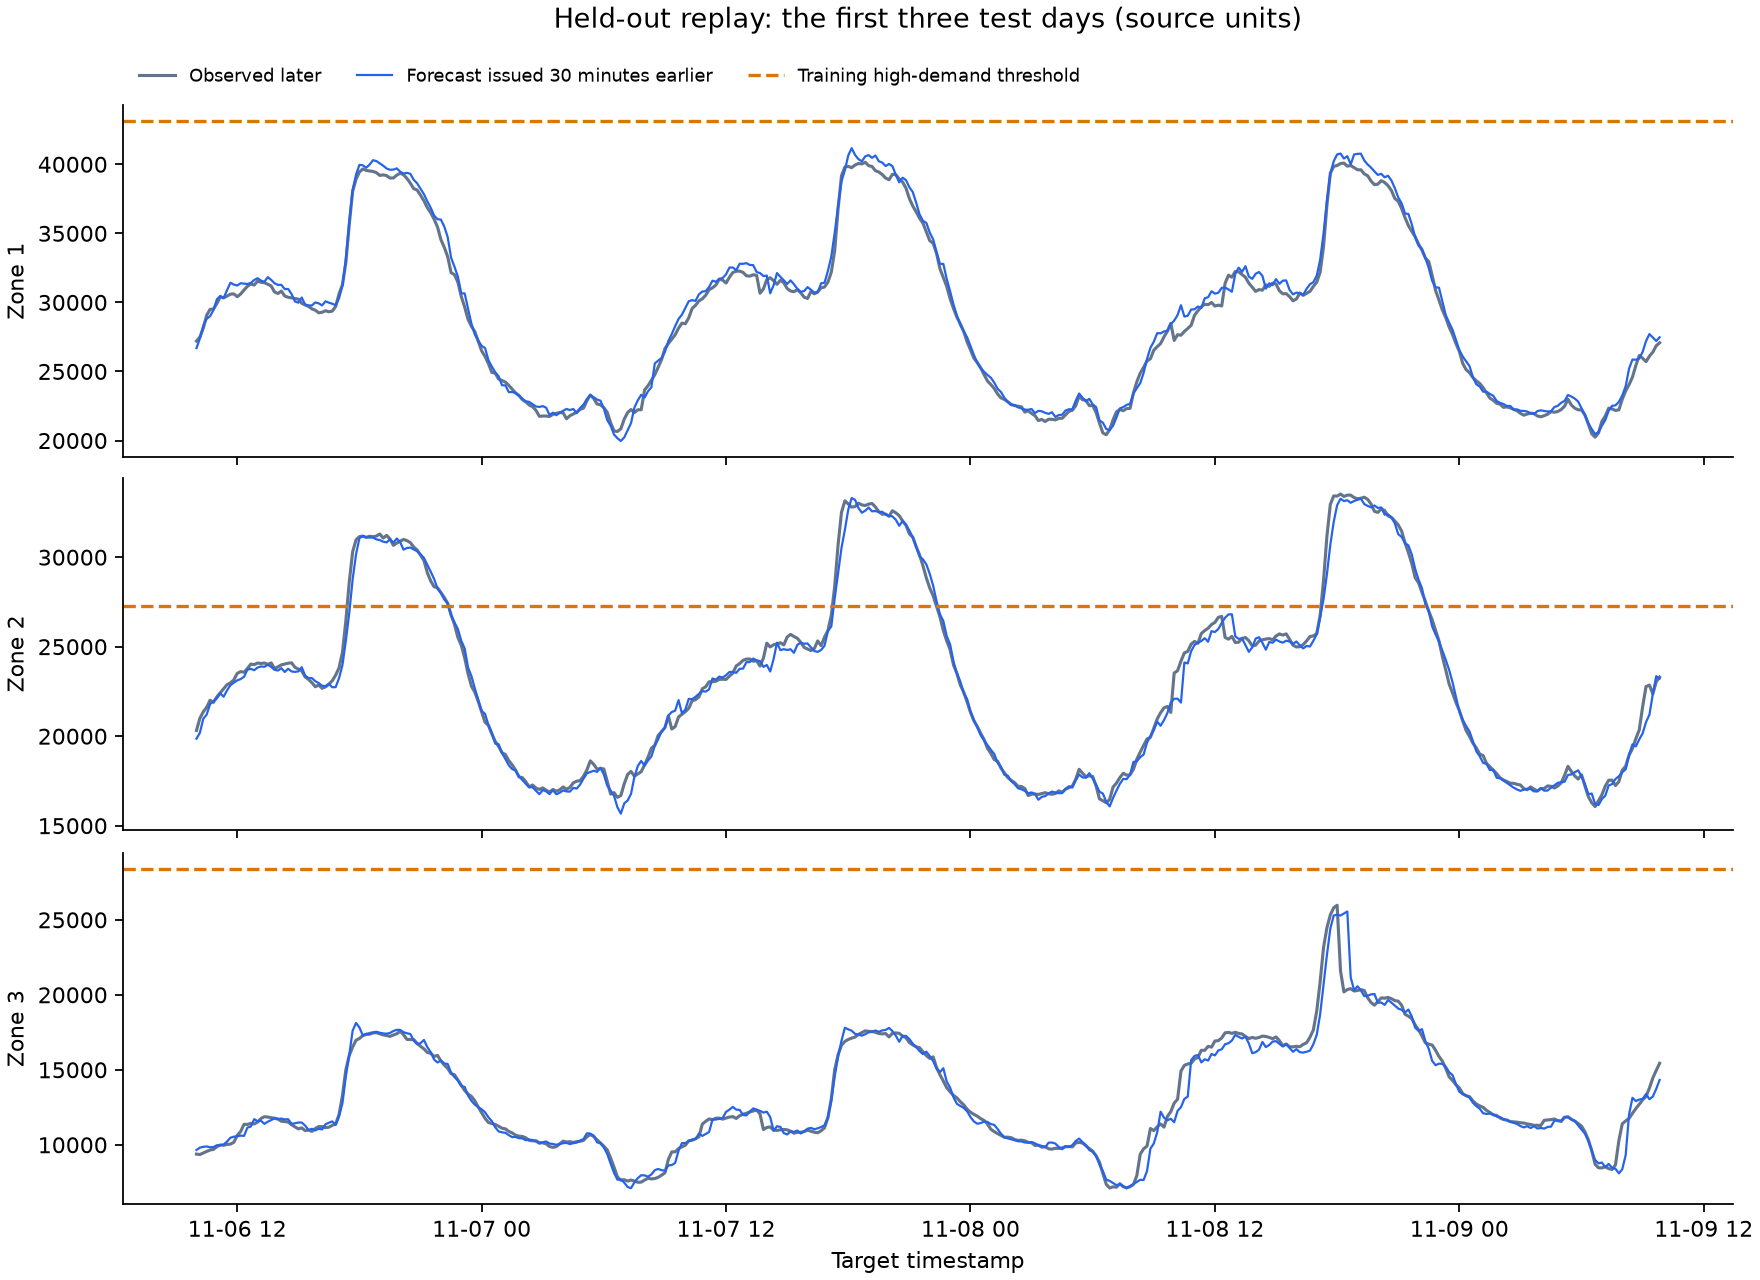

## 6. High-demand classification and failure analysis

Each zone's label uses the training 90th percentile. Candidates include logistic regression, perceptron, Gaussian Naive Bayes, KNN, tree, forest and linear SVM, with an always-normal baseline. Score cutoffs use validation negatives and target at most 5% validation false positives. Selection maximizes validation recall, then precision, then training speed.

Two score-based strategies share this validation budget: direct classification and the selected numeric forecast score. Their later test false-positive rates can differ. A separate forecast-above-high-demand-threshold comparator has a different operating policy.

Zone 3 has no positive validation or test events at its fixed training threshold. Recall is unavailable. Its always-normal placeholder is explicitly **not validated**. Zone 1 has only nine positive test samples, so apparently perfect recall is fragile and its alert precision is low. Neighboring ten-minute samples are correlated; sample counts are not counts of independent incidents.

In [7]:
print("Selected classifiers:", summary["selected_classifiers"])
print("Validation status:", summary["validation_alert_status"])
alerts = pd.read_csv(ROOT / "reports/alerts_test.csv")
print(alerts[["zone","strategy","precision","recall","false_positive_rate","tp","fp","fn","positive_events"]].to_string(index=False))


Selected classifiers: {'zone_1': 'Perceptron', 'zone_2': 'Linear SVM', 'zone_3': 'Always normal'}
Validation status: {'zone_1': 'Selected on validation recall at the fixed false-positive budget.', 'zone_2': 'Selected on validation recall at the fixed false-positive budget.', 'zone_3': 'Not validated: no positive validation events; always-normal placeholder.'}
  zone                                      strategy  precision   recall  false_positive_rate   tp  fp  fn  positive_events
zone_1  Direct classifier (validation 5% FPR budget)   0.041096 1.000000             0.026748    9 210   0                9
zone_1     Forecast score (validation 5% FPR budget)   0.025281 1.000000             0.044198    9 347   0                9
zone_1 Forecast above training high-demand threshold   0.714286 0.555556             0.000255    5   2   4                9
zone_2  Direct classifier (validation 5% FPR budget)   0.857786 0.996341             0.053136 1906 316   7             1913
zone_2     Forecas

The initial test does not establish hypothesis H1. In zone 2, direct classification has fewer false alarms but misses seven positive samples instead of six for the forecast-score strategy. Zone 1 has the same detected positives and fewer false alarms, but only nine positive samples. These are descriptive comparisons under one provisional split, without an inferential significance claim.

## 7. Component ablations

The selected linear configuration is refitted after removing weather or all zone-demand history. Both ablations keep identical training/validation samples. The held-out test does not select ablation variants.

Demand history is essential in this setup. Removing weather slightly lowers validation MAE, so the present evidence does not show a meaningful weather benefit. The original full candidate remains the already-frozen test model.

In [8]:
ablation = pd.read_csv(ROOT / "reports/ablation_validation.csv")
print(ablation[ablation.zone == "average"][["model","mae","rmse","r2"]].to_string(index=False))


                 model         mae        rmse        r2
Without demand history 4881.074843 5490.492427 -1.823913
       Without weather  318.879746  464.715724  0.989747
   Full selected model  318.988078  464.876867  0.989745


## 8. Demo and reproducibility

Run `run_demo.ps1`, then open http://localhost:8501. Replay controls choose a zone, day and origin. Reveal later observations to see absolute error. The evidence tab shows the exact generated tables. The app is not a live feed and it does not yet produce a calibrated uncertainty interval or an anomaly fallback.

Regenerate by running the source modules in order: `gridwatch.data`, then `gridwatch.experiment`. `requirements.txt` pins installed versions. Configurations and random seed are in source/config. Tests check the temporal contract and tied alert score thresholds.

## 9. Proposed final contribution and remaining chapters

1. **Risk-aware alerts with regime adaptation:** compare direct alerts to numeric forecast scores, then evaluate past-only regime specialists. Existing Tetouan research already uses clustering, so clustering alone is not a novelty claim.
2. **A reliability gate with fallback:** detect problematic inputs or already-observed forecast residuals and use a documented backup forecast. Evaluate clean-data false alarms and explicitly synthetic sensor faults. The source has no real fault labels.

Chapter 11: small MLP/LSTM candidates. Chapter 12: regime clustering. Chapter 13: await course material. Chapter 14: feature selection/PCA. Chapter 15: anomaly gate/fallback. Add a 60-minute horizon and rolling chronological validation when finalizing the evaluation protocol with other groups. These sections are ready for later experiments and contain no fictional results.

## 10. Related work and submission details

[Alsalem (2025), Scientific Reports](https://www.nature.com/articles/s41598-025-91123-8) demonstrates existing clustering/ML work on Tetouan. Published scores cannot be directly ranked against these results without matching horizons, features and splits. Expand the literature review before final submission.

Group name and member contributions: pending real group information. Each member must understand and verify the material they present. The final contribution must be demonstrated by controlled experiments; this milestone establishes the reproducible base.